In [49]:
#BIVARIATE ANALYSIS

In [50]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [51]:
cleaned_df = pd.read_csv("cleaned_itsm_data.csv")

print("Cleaned dataset loaded successfully!")
print("Shape:", cleaned_df.shape)

Cleaned dataset loaded successfully!
Shape: (360000, 29)


In [52]:
categorical_columns = [
    "ticket_type",
    "category",
    "sub_category",
    "priority",
    "impact",
    "urgency",
    "ticket_status",
    "source_channel",
    "resolution_code",
    "created_month",
    "sla_type",
    "sla_status"
]

for col in categorical_columns:
    print(f"\n{col}:")
    print(cleaned_df[col].value_counts(dropna=False))


ticket_type:
ticket_type
Incident    360000
Name: count, dtype: int64

category:
category
Software    360000
Name: count, dtype: int64

sub_category:
sub_category
Patch Update    360000
Name: count, dtype: int64

priority:
priority
P3    360000
Name: count, dtype: int64

impact:
impact
Medium    360000
Name: count, dtype: int64

urgency:
urgency
Medium    360000
Name: count, dtype: int64

ticket_status:
ticket_status
Closed    360000
Name: count, dtype: int64

source_channel:
source_channel
Email    360000
Name: count, dtype: int64

resolution_code:
resolution_code
User Educated               45196
Known Error Workaround      45170
Patch Applied               45168
Configuration Updated       45082
Resolved by KB Article      44998
Access Granted              44900
Vendor Fix Applied          44878
Password Reset Completed    44608
Name: count, dtype: int64

created_month:
created_month
2021-06-01    360000
Name: count, dtype: int64

sla_type:
sla_type
First Response    180000
Resolut

In [53]:
resolution_sla = pd.crosstab(
    cleaned_df["resolution_code"],
    cleaned_df["sla_status"]
)

print(resolution_sla)

sla_status                Breached   Met
resolution_code                         
Access Granted               38658  6242
Configuration Updated        38823  6259
Known Error Workaround       38889  6281
Password Reset Completed     38424  6184
Patch Applied                38959  6209
Resolved by KB Article       38698  6300
User Educated                38868  6328
Vendor Fix Applied           38687  6191


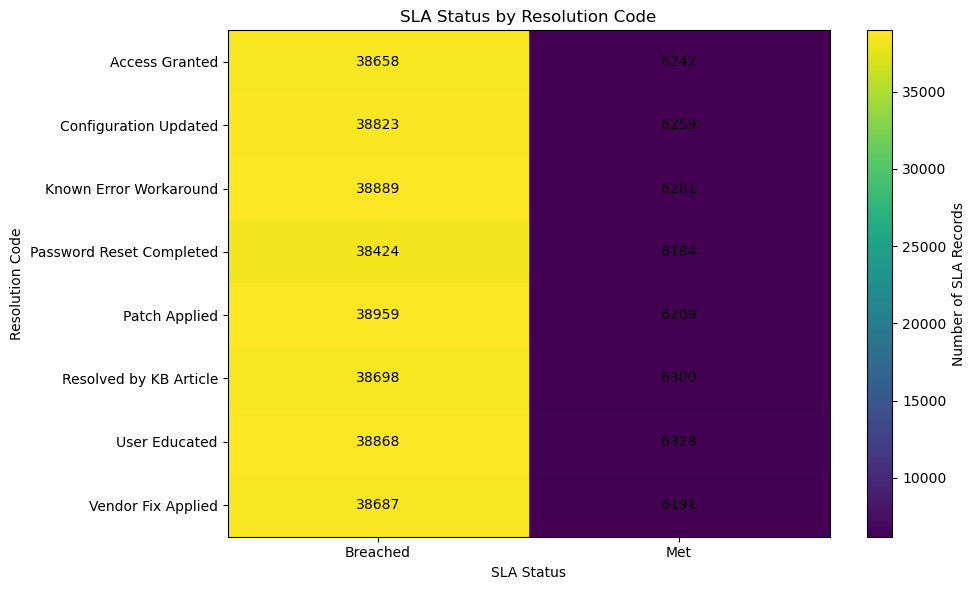

In [54]:
plt.figure(figsize=(10, 6))

plt.imshow(resolution_sla, aspect="auto")

plt.title("SLA Status by Resolution Code")
plt.xlabel("SLA Status")
plt.ylabel("Resolution Code")

plt.xticks(
    range(len(resolution_sla.columns)),
    resolution_sla.columns
)

plt.yticks(
    range(len(resolution_sla.index)),
    resolution_sla.index
)

for i in range(len(resolution_sla.index)):
    for j in range(len(resolution_sla.columns)):
        plt.text(
            j,
            i,
            resolution_sla.iloc[i, j],
            ha="center",
            va="center"
        )

plt.colorbar(label="Number of SLA Records")

plt.tight_layout()
plt.show()

In [55]:
actual_sla = cleaned_df.groupby("sla_status")[
    "actual_minutes"
].mean()

print(actual_sla)

sla_status
Breached    3535.934163
Met           62.496640
Name: actual_minutes, dtype: float64


<Figure size 900x600 with 0 Axes>

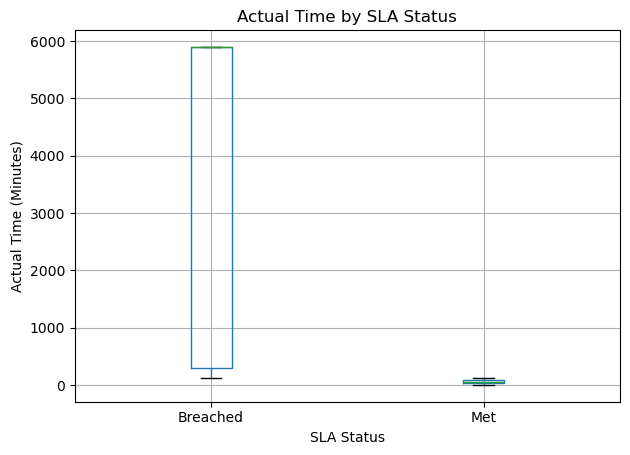

In [56]:
plt.figure(figsize=(9, 6))

cleaned_df.boxplot(
    column="actual_minutes",
    by="sla_status"
)

plt.title("Actual Time by SLA Status")
plt.suptitle("")
plt.xlabel("SLA Status")
plt.ylabel("Actual Time (Minutes)")

plt.tight_layout()
plt.show()

In [57]:
breach_sla = cleaned_df.groupby("sla_status")[
    "breach_minutes"
].mean()

print(breach_sla)

sla_status
Breached    2649.497384
Met            0.000000
Name: breach_minutes, dtype: float64


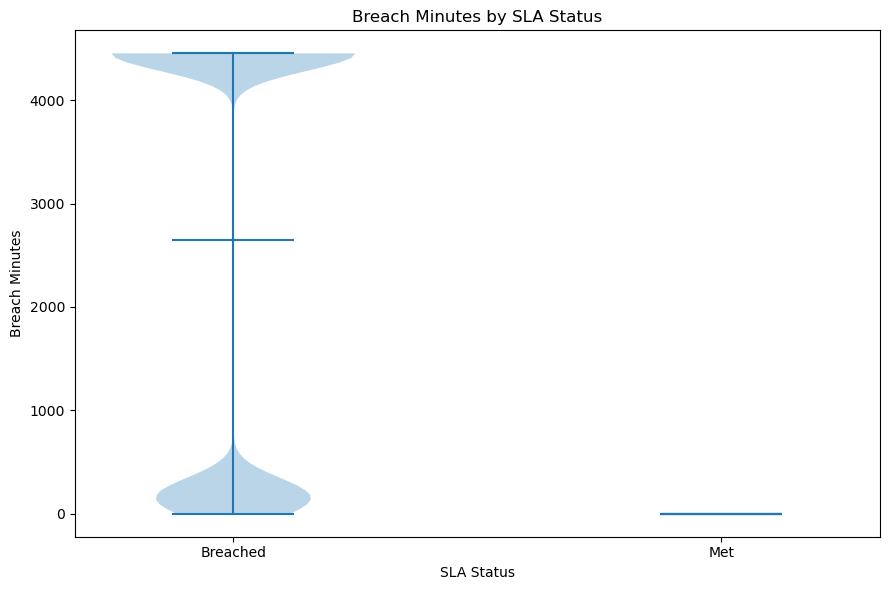

In [58]:
plt.figure(figsize=(9, 6))

data = [
    cleaned_df.loc[cleaned_df["sla_status"] == "Breached", "breach_minutes"].dropna(),
    cleaned_df.loc[cleaned_df["sla_status"] == "Met", "breach_minutes"].dropna()
]

plt.violinplot(
    data,
    showmeans=True,
    showmedians=True
)

plt.title("Breach Minutes by SLA Status")
plt.xlabel("SLA Status")
plt.ylabel("Breach Minutes")

plt.xticks(
    [1, 2],
    ["Breached", "Met"]
)

plt.tight_layout()
plt.show()

In [59]:
resolution_time = cleaned_df.groupby("resolution_code")[
    "actual_minutes"
].mean()

print(resolution_time)

resolution_code
Access Granted              3053.595702
Configuration Updated       3053.758950
Known Error Workaround      3053.386451
Password Reset Completed    3053.926941
Patch Applied               3053.766361
Resolved by KB Article      3053.548247
User Educated               3052.860740
Vendor Fix Applied          3053.724297
Name: actual_minutes, dtype: float64


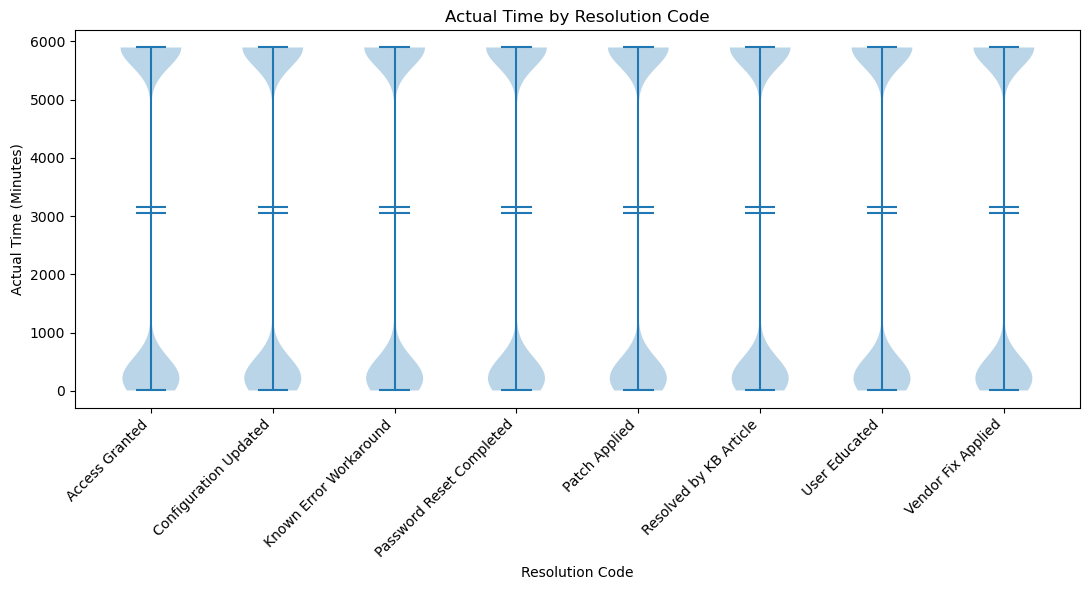

In [60]:
plt.figure(figsize=(11, 6))

data = [
    cleaned_df.loc[
        cleaned_df["resolution_code"] == code,
        "actual_minutes"
    ].dropna()
    for code in resolution_time.index
]

plt.violinplot(
    data,
    showmeans=True,
    showmedians=True
)

plt.title("Actual Time by Resolution Code")
plt.xlabel("Resolution Code")
plt.ylabel("Actual Time (Minutes)")

plt.xticks(
    range(1, len(resolution_time.index) + 1),
    resolution_time.index,
    rotation=45,
    ha="right"
)

plt.tight_layout()

plt.savefig("Resolution_Code_vs_Actual_Time.svg", format="svg")

plt.show()

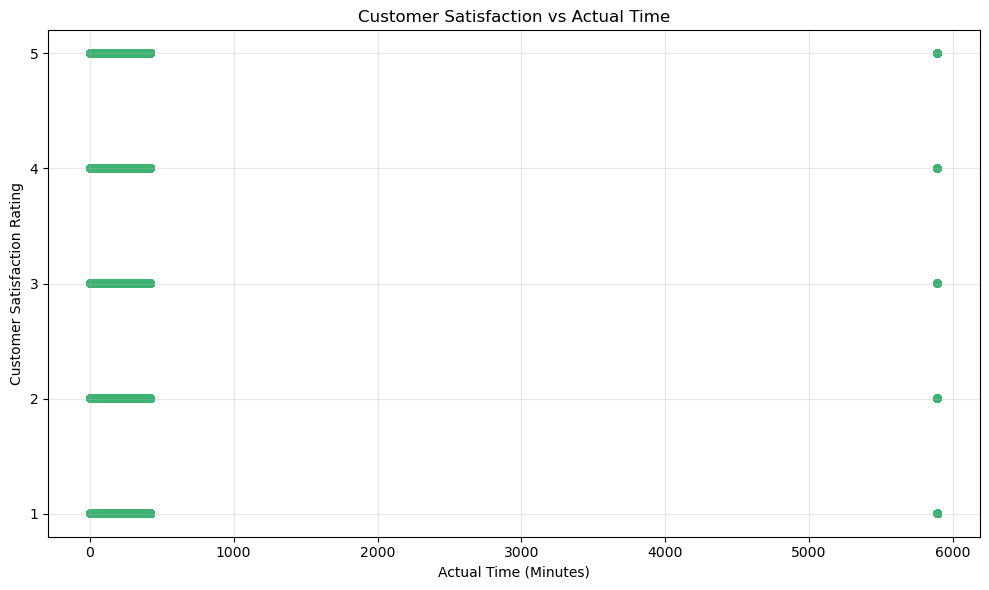

In [61]:
csat_time = cleaned_df[
    ["customer_satisfaction_rating", "actual_minutes"]
].dropna()

plt.figure(figsize=(10, 6))

plt.scatter(
    csat_time["actual_minutes"],
    csat_time["customer_satisfaction_rating"],
    alpha=0.3,
    color="mediumseagreen",
    edgecolors="none"
)

plt.title("Customer Satisfaction vs Actual Time")
plt.xlabel("Actual Time (Minutes)")
plt.ylabel("Customer Satisfaction Rating")
plt.yticks([1, 2, 3, 4, 5])
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [62]:
sla_type_status = pd.crosstab(
    cleaned_df["sla_type"],
    cleaned_df["sla_status"]
)

print(sla_type_status)

sla_status      Breached    Met
sla_type                       
First Response    130006  49994
Resolution        180000      0


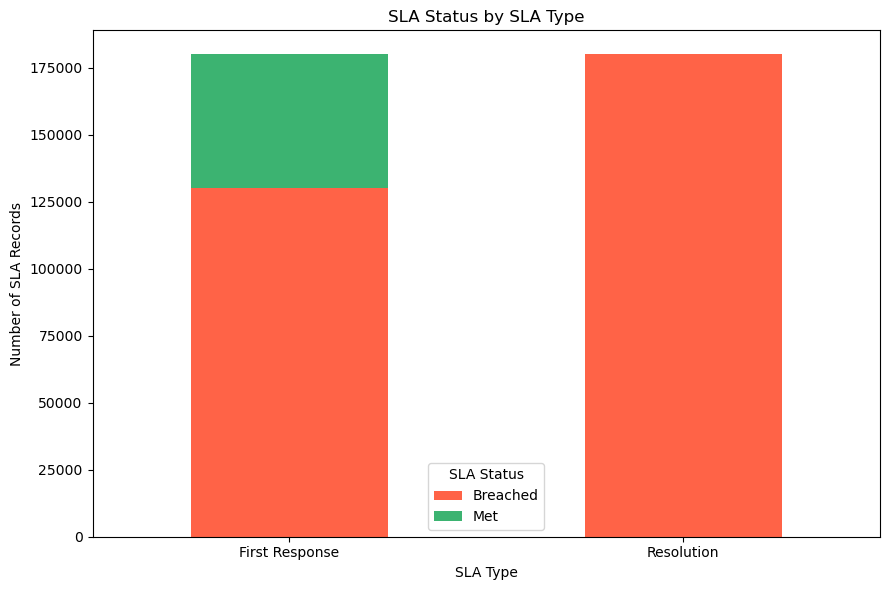

In [63]:
sla_type_status.plot(
    kind="bar",
    stacked=True,
    figsize=(9, 6),
    color=["tomato", "mediumseagreen"]
)

plt.title("SLA Status by SLA Type")
plt.xlabel("SLA Type")
plt.ylabel("Number of SLA Records")
plt.xticks(rotation=0)
plt.legend(title="SLA Status")

plt.tight_layout()
plt.show()

In [64]:
variance_status = cleaned_df.groupby("sla_status")[
    "sla_variance_minutes"
].mean()

print(variance_status)

sla_status
Breached    2649.497384
Met          -57.503360
Name: sla_variance_minutes, dtype: float64


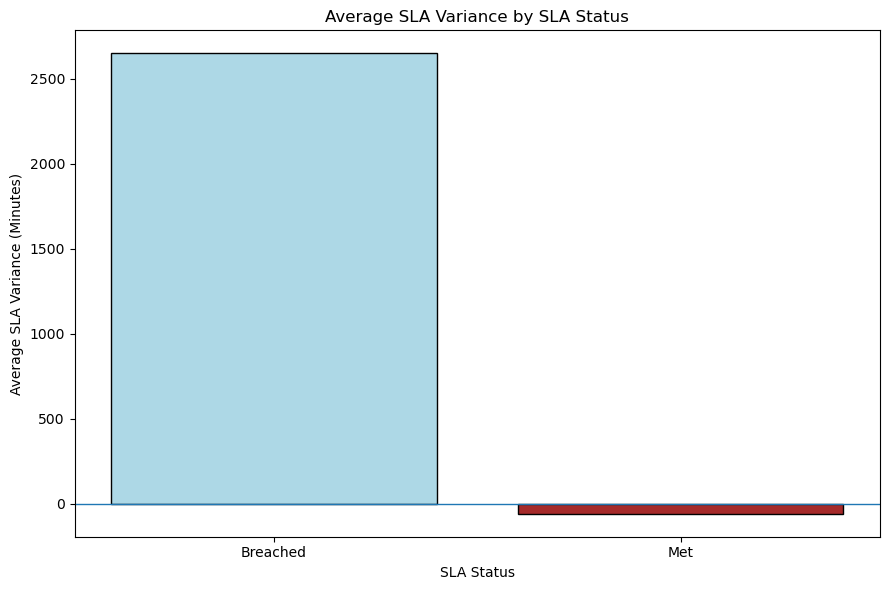

In [65]:
plt.figure(figsize=(9, 6))

plt.bar(
    variance_status.index,
    variance_status.values,
    color=["lightblue", "brown"],
    edgecolor="black"
)

plt.title("Average SLA Variance by SLA Status")
plt.xlabel("SLA Status")
plt.ylabel("Average SLA Variance (Minutes)")
plt.axhline(0, linewidth=1)

plt.tight_layout()

plt.savefig(
    "SLA_Variance_vs_SLA_Status.svg",
    format="svg"
)

plt.show()

In [ ]:
# Bivariate Analysis Completed